# Airline Fare Prediction

### Estimating flight ticket prices from booking attributes using machine learning

**Author:** Harsh Mishra

---

### About this project

Flight prices are notoriously unpredictable to the average traveller, yet they follow patterns that are learnable from data — airline, route, cabin class, number of stops, and especially how far in advance a ticket is booked all leave a measurable fingerprint on the final fare.

This project builds and compares five regression models to estimate flight fares for Indian domestic routes, with a particular focus on **how booking lead time (days left before departure) drives price**. Beyond just picking the best model, the goal is to produce a result that is genuinely useful: an estimated fare with a realistic error range, validated not just on random held-out data but on **routes and flights the model has never seen before** — the scenario that actually matters in practice.

The trained model is exported at the end of this notebook so it can be served through a web application, where a user enters flight details and receives an estimated fare, an expected error range, and the model behind the prediction.

**Dataset:** [Flight Price Prediction](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction) (Kaggle, Shubham Bathwal) — `Clean_Dataset.csv`, ~300,000 domestic flight bookings across India's six major metro cities.

---

### Workflow

1. Setup and data loading
2. Data cleaning
3. Exploratory data analysis
4. Feature engineering and encoding
5. Train/test split (leak-free pipelines)
6. Training five regression models — Linear, Polynomial, Decision Tree, Random Forest, Gradient Boosting
7. Model comparison — R², MSE, RMSE, MAE, k-fold cross-validation
8. Residual analysis
9. Group-based validation — generalisation to new routes and new flights
10. Feature importance
11. Fare-vs-lead-time analysis for booking timing
12. Final analysis and conclusions
13. Saving the model and metadata for deployment


## 1. Setup

In [5]:
# Install any missing packages (uncomment if running fresh in Colab)
# !pip install -q scikit-learn pandas numpy matplotlib seaborn joblib kaggle


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, KFold, GroupKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


### 1.1 Get the dataset

**Option A — Manual (recommended if you already downloaded it):**
Upload `Clean_Dataset.csv` to the Colab file browser (left sidebar → folder icon → upload), then just run the loading cell below.

**Option B — Kaggle API (run this cell only if you don't have the file yet):**
1. Go to Kaggle → your profile → Account → *Create New API Token*. This downloads `kaggle.json`.
2. Run the cell below and upload `kaggle.json` when prompted.


In [7]:
# OPTION B: Kaggle API download (skip this cell if you already uploaded Clean_Dataset.csv)
DOWNLOAD_VIA_KAGGLE_API = False  # set True if you want to use this method

if DOWNLOAD_VIA_KAGGLE_API:
    from google.colab import files
    uploaded = files.upload()  # select kaggle.json here

    import os
    os.makedirs("/root/.kaggle", exist_ok=True)
    !cp kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
    !pip install -q kaggle
    !kaggle datasets download -d shubhambathwal/flight-price-prediction
    !unzip -o flight-price-prediction.zip


In [8]:
from google.colab import files

uploaded = files.upload()  # a file picker will pop up — select Clean_Dataset.csv from your computer

DATA_PATH = "Clean_Dataset.csv"
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Saving Clean_Dataset.csv to Clean_Dataset.csv
Shape: (300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### 1.2 Sanity check — confirm this is the right (domestic) dataset

Before doing anything else, confirm the dataset is what we expect: Indian domestic flights between the 6 metro cities, with a `days_left` column.


In [9]:
expected_cities = {"Delhi", "Mumbai", "Bangalore", "Kolkata", "Hyderabad", "Chennai"}

print("Source cities:", sorted(df_raw["source_city"].unique()))
print("Destination cities:", sorted(df_raw["destination_city"].unique()))
print("Columns:", df_raw.columns.tolist())
print("days_left range:", df_raw["days_left"].min(), "to", df_raw["days_left"].max())

assert set(df_raw["source_city"].unique()) <= expected_cities, "Unexpected source cities found — check the dataset!"
assert set(df_raw["destination_city"].unique()) <= expected_cities, "Unexpected destination cities found — check the dataset!"
print("\nDataset check passed: domestic flights between the 6 expected metro cities.")


Source cities: ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
Destination cities: ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
Columns: ['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']
days_left range: 1 to 49

Dataset check passed: domestic flights between the 6 expected metro cities.


## 2. Data Cleaning

Steps:
- Drop the unnamed index column (an artifact of the CSV export).
- Keep `flight` aside separately (useful later for a strict "unseen flight" validation) but drop it from the modelling features, since it behaves like a near-unique ID and would cause overfitting.
- Map `stops` from text to numeric.
- Check for nulls and duplicates.
- Engineer `route`.


In [10]:
df = df_raw.copy()

# Drop the stray index column if present
df = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")

print("Nulls per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique flights (IDs):", df["flight"].nunique())


Nulls per column:
 airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Duplicate rows: 0

Unique flights (IDs): 1561


In [11]:
# Map stops to numeric
stop_map = {"zero": 0, "one": 1, "two_or_more": 2}
df["stops_num"] = df["stops"].map(stop_map)

# Engineer route
df["route"] = df["source_city"] + "_" + df["destination_city"]

# Keep flight code aside for later group validation, but we will not feed it to the model
flight_ids = df["flight"].copy()

print(df[["airline", "source_city", "destination_city", "route", "stops", "stops_num", "class", "duration", "days_left", "price"]].head())


    airline source_city destination_city         route stops  stops_num  \
0  SpiceJet       Delhi           Mumbai  Delhi_Mumbai  zero          0   
1  SpiceJet       Delhi           Mumbai  Delhi_Mumbai  zero          0   
2   AirAsia       Delhi           Mumbai  Delhi_Mumbai  zero          0   
3   Vistara       Delhi           Mumbai  Delhi_Mumbai  zero          0   
4   Vistara       Delhi           Mumbai  Delhi_Mumbai  zero          0   

     class  duration  days_left  price  
0  Economy      2.17          1   5953  
1  Economy      2.33          1   5953  
2  Economy      2.17          1   5956  
3  Economy      2.25          1   5955  
4  Economy      2.33          1   5955  


In [12]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,300153,6,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight,300153,1561,UK-706,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,300153,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,300153,6,Morning,71146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,300153,3,one,250863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,300153,6,Night,91538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,300153,6,Mumbai,59097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300153,2,Economy,206666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,300153.0,NaN,NaN,NaN,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,NaN,NaN,NaN,26.004751,13.561004,1.0,15.0,26.0,38.0,49.0


## 3. Exploratory Data Analysis (EDA)

We look at:
1. Distribution of `price`
2. Price by class
3. Price by airline, stops, departure time
4. **Mean price vs `days_left`** — the key relationship this project focuses on
5. Mean price by route
6. Correlation heatmap


### 3.1 Price distribution

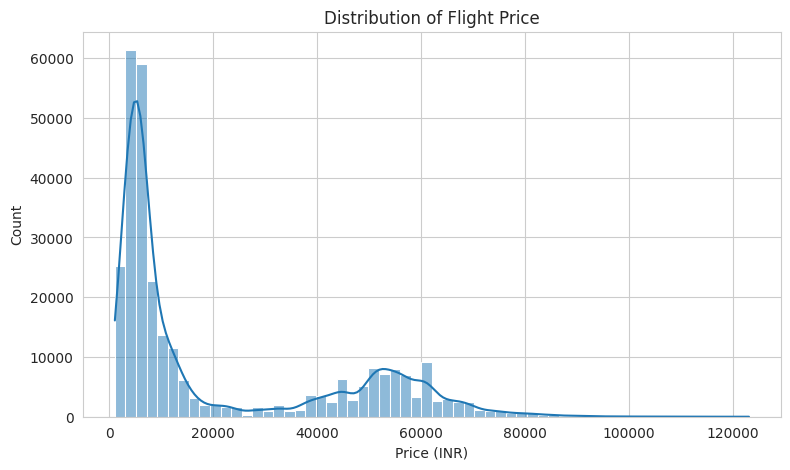

Price skewness: 1.0613772532064343


In [13]:
plt.figure()
sns.histplot(df["price"], bins=60, kde=True)
plt.title("Distribution of Flight Price")
plt.xlabel("Price (INR)")
plt.show()

print("Price skewness:", df["price"].skew())


**Interpretation:** *(write 1-2 sentences here once you see the plot — expect a right-skewed distribution, and likely a visible second cluster for Business class fares.)*

### 3.2 Price by class

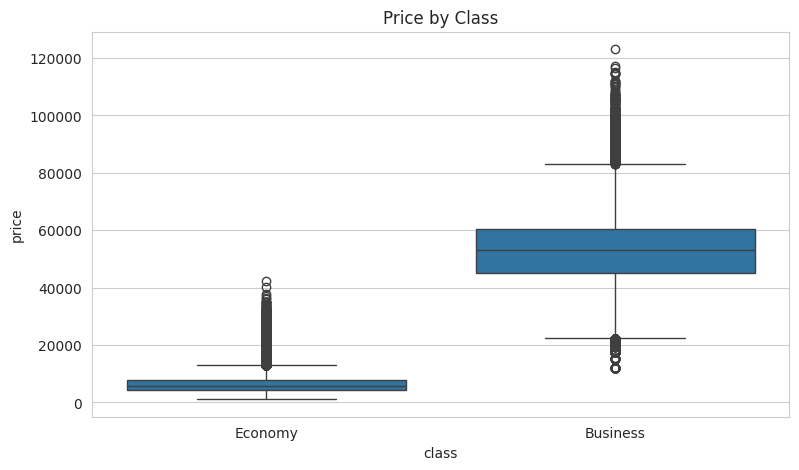

                  mean   median   count
class                                  
Business  52540.081124  53164.0   93487
Economy    6572.342383   5772.0  206666


In [14]:
plt.figure()
sns.boxplot(data=df, x="class", y="price")
plt.title("Price by Class")
plt.show()

print(df.groupby("class")["price"].agg(["mean", "median", "count"]))


**Interpretation:** *(note how much more expensive Business is than Economy, and comment on whether it's worth modelling separately.)*

### 3.3 Price by airline, stops, and departure time

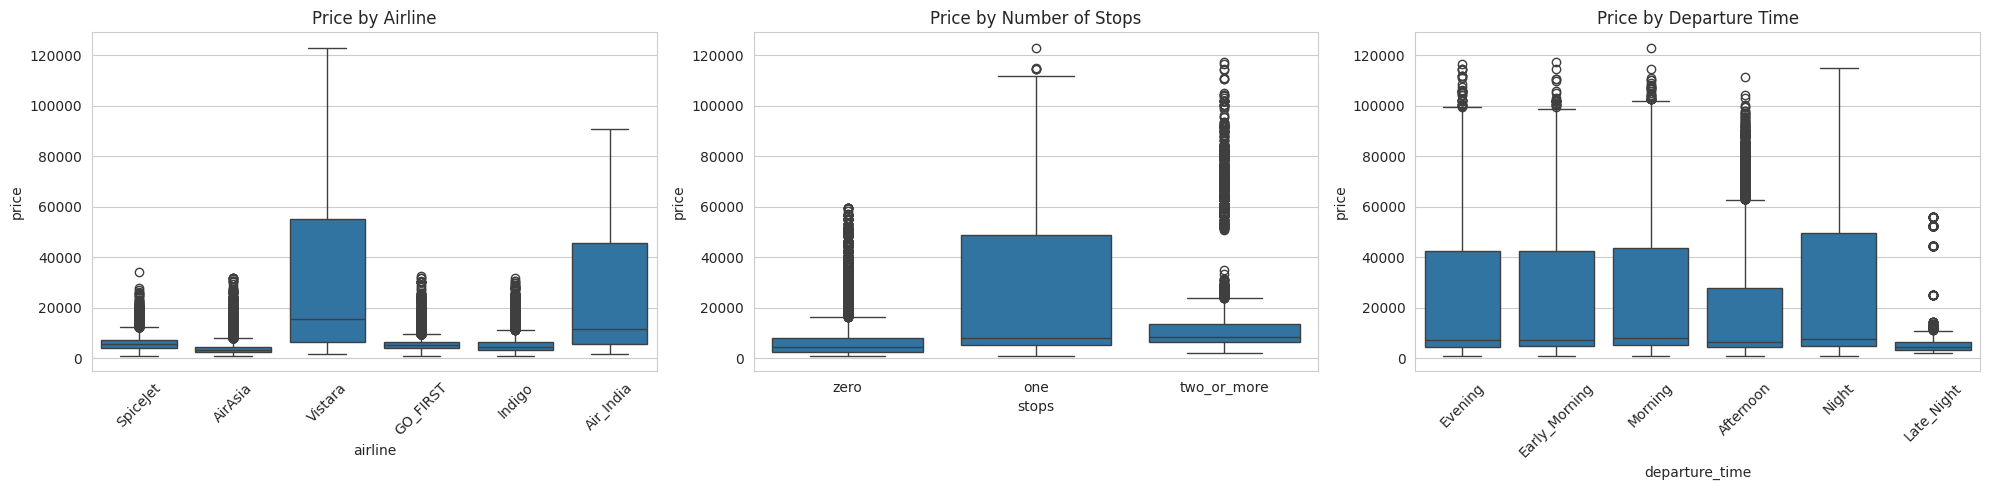

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(data=df, x="airline", y="price", ax=axes[0])
axes[0].set_title("Price by Airline")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="stops", y="price", ax=axes[1])
axes[1].set_title("Price by Number of Stops")

sns.boxplot(data=df, x="departure_time", y="price", ax=axes[2])
axes[2].set_title("Price by Departure Time")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Interpretation:** *(name the most and least expensive airlines, and note whether more stops means higher or lower price — direct flights are often priced higher for convenience.)*

### 3.4 Price vs `days_left` — the key relationship

This is the central question of this project: **do fares rise sharply as departure approaches?**


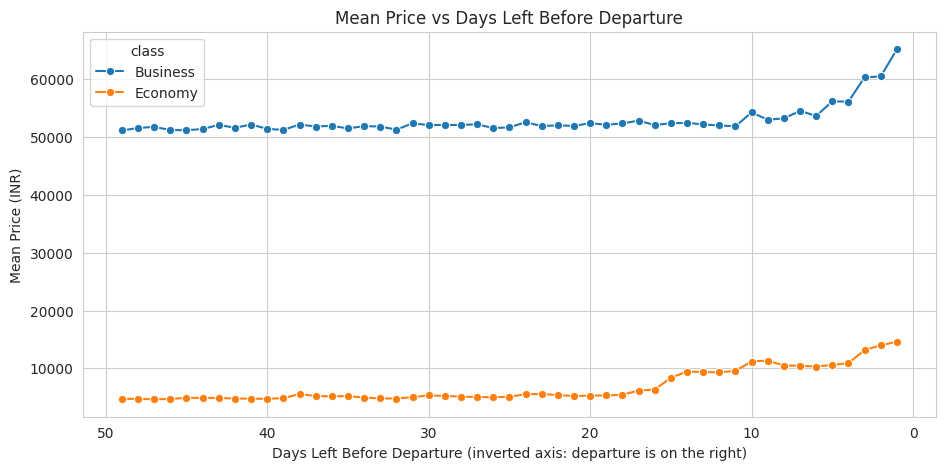

In [16]:
# Mean price by exact days_left, split by class
lead_time_df = df.groupby(["days_left", "class"])["price"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=lead_time_df, x="days_left", y="price", hue="class", marker="o")
plt.gca().invert_xaxis()  # so departure (0) is on the right, matching real booking timelines
plt.title("Mean Price vs Days Left Before Departure")
plt.xlabel("Days Left Before Departure (inverted axis: departure is on the right)")
plt.ylabel("Mean Price (INR)")
plt.show()


In [17]:
# Correlation between days_left and price (overall and by class)
print("Overall correlation (days_left, price):", df["days_left"].corr(df["price"]))
for cls in df["class"].unique():
    subset = df[df["class"] == cls]
    print(f"{cls}: correlation = {subset['days_left'].corr(subset['price']):.4f}")


Overall correlation (days_left, price): -0.09194853217143847
Economy: correlation = -0.5596
Business: correlation = -0.0913


class               Business       Economy
days_left_band                            
1-3             60795.491925  13807.991696
4-7             55062.248658  10565.422061
8-14            52692.903064  10047.811421
15-30           52126.291536   5587.527179
30+             51648.559844   4919.203683


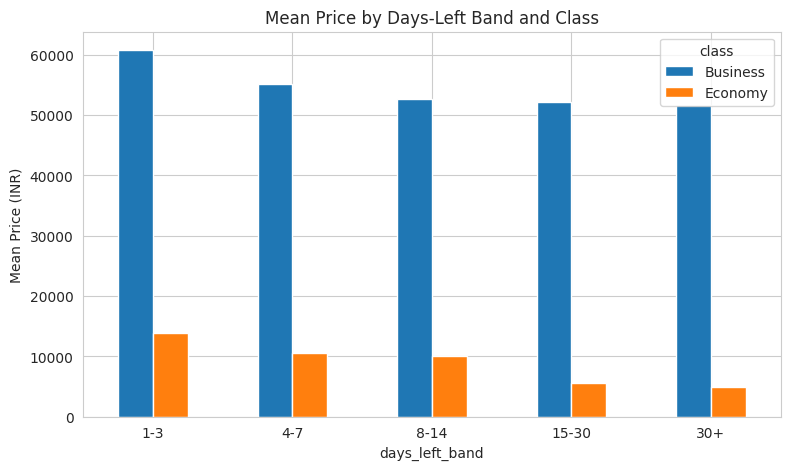

In [18]:
# Bucket days_left into bands for an easy-to-read table
bins = [0, 3, 7, 14, 30, 50]
labels = ["1-3", "4-7", "8-14", "15-30", "30+"]
df["days_left_band"] = pd.cut(df["days_left"], bins=bins, labels=labels, include_lowest=True)

band_table = df.groupby(["days_left_band", "class"])["price"].mean().unstack()
print(band_table)

band_table.plot(kind="bar", figsize=(9, 5))
plt.title("Mean Price by Days-Left Band and Class")
plt.ylabel("Mean Price (INR)")
plt.xticks(rotation=0)
plt.show()


**Interpretation:** *(this is your most important EDA finding — write clearly whether the jump close to departure is present in your data, how large it is in percentage terms, and note that the raw linear correlation with `days_left` may look weak even when a real non-linear effect exists — that gap is itself evidence of non-linearity.)*

### 3.5 Mean price by route

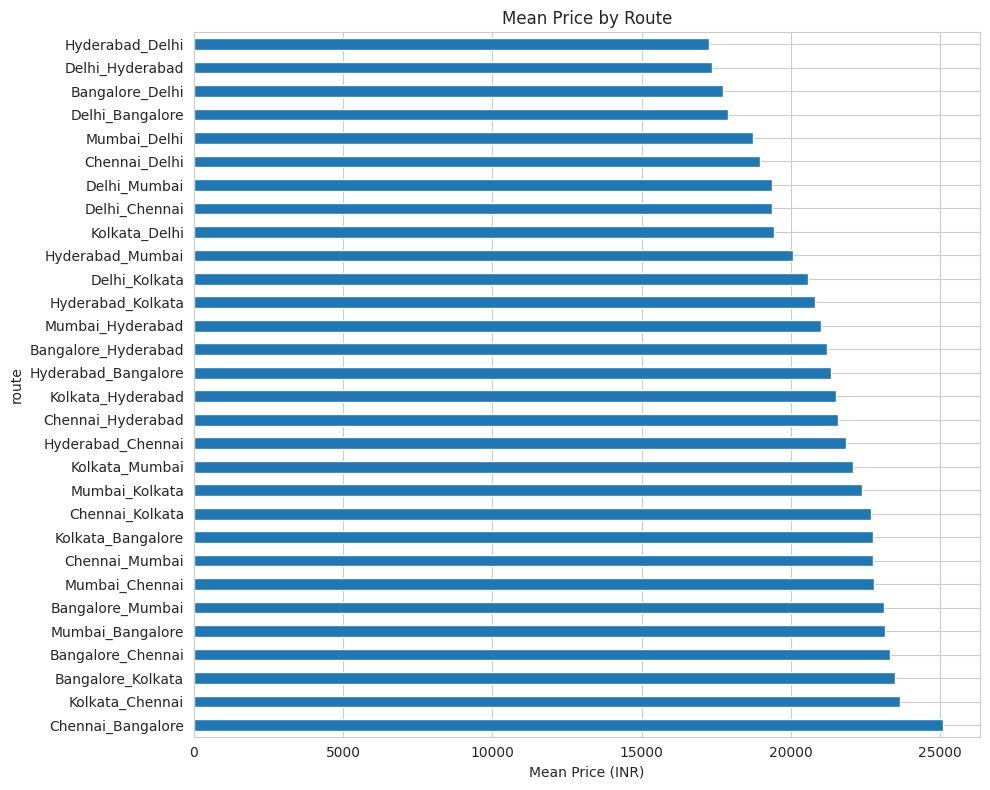

In [19]:
route_price = df.groupby("route")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
route_price.plot(kind="barh")
plt.title("Mean Price by Route")
plt.xlabel("Mean Price (INR)")
plt.tight_layout()
plt.show()


### 3.6 Correlation heatmap (numeric features)

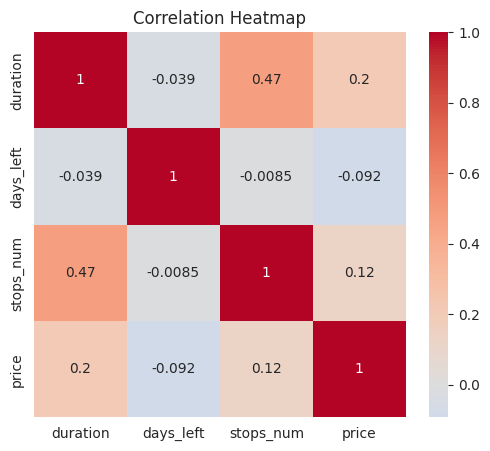

In [20]:
numeric_cols = ["duration", "days_left", "stops_num", "price"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


### 3.7 Duration vs price

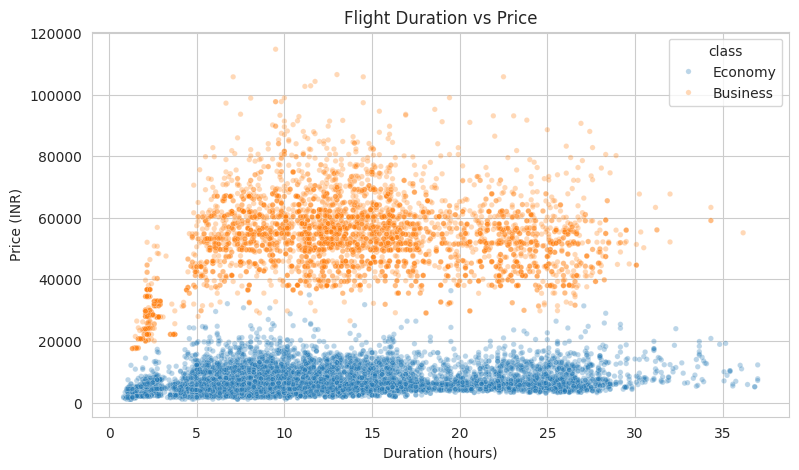

In [21]:
plt.figure(figsize=(9, 5))
sample_for_scatter = df.sample(n=min(15_000, len(df)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample_for_scatter, x="duration", y="price", hue="class", alpha=0.3, s=15)
plt.title("Flight Duration vs Price")
plt.xlabel("Duration (hours)")
plt.ylabel("Price (INR)")
plt.show()


**Interpretation:** *(note whether longer flights cost more overall, and whether the relationship differs between Economy and Business.)*

### 3.8 Price distribution by number of stops (violin plot)

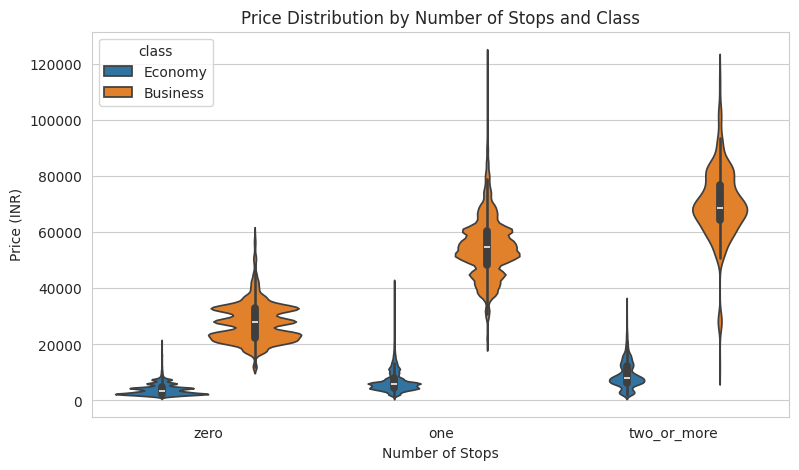

In [22]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x="stops", y="price", hue="class", split=False)
plt.title("Price Distribution by Number of Stops and Class")
plt.xlabel("Number of Stops")
plt.ylabel("Price (INR)")
plt.show()


**Interpretation:** *(note not just the average but the spread — does adding a stop widen or narrow the range of likely fares?)*

### 3.9 Average price heatmap — route x class

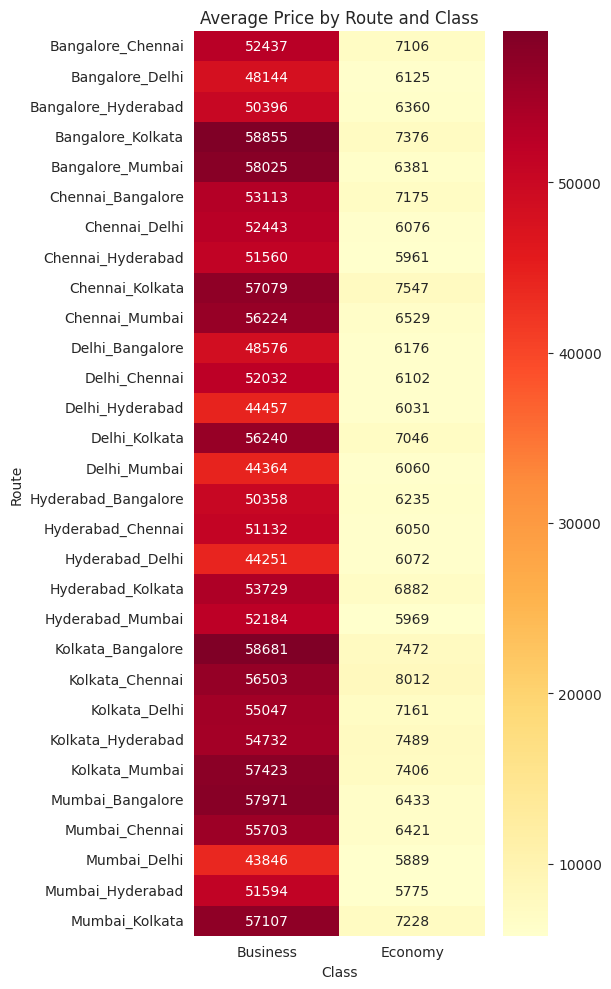

In [23]:
route_class_avg = df.pivot_table(index="route", columns="class", values="price", aggfunc="mean")

plt.figure(figsize=(6, 10))
sns.heatmap(route_class_avg, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Average Price by Route and Class")
plt.xlabel("Class")
plt.ylabel("Route")
plt.tight_layout()
plt.show()


**Interpretation:** *(identify the most and least expensive route-class combinations, and note whether the Business premium is consistent across routes or varies noticeably.)*

## 4. Feature Engineering and Encoding

- Numeric features: `duration`, `days_left`, `stops_num`
- Categorical features: `airline`, `source_city`, `destination_city`, `departure_time`, `arrival_time`, `class`, `route`
- Encoding: One-Hot Encoding for categorical features, done **inside** a `ColumnTransformer` so it is fit only on training data (no leakage).
- For Polynomial Regression, polynomial terms are applied only to `duration` and `days_left` — not to the one-hot columns — to avoid a feature-count explosion.


In [24]:
target = "price"
num_cols = ["duration", "days_left", "stops_num"]
cat_cols = ["airline", "source_city", "destination_city", "departure_time", "arrival_time", "class", "route"]

X = df[num_cols + cat_cols].copy()
y = df[target].copy()
groups_route = df["route"].copy()
groups_flight = flight_ids.copy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups_route, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (240122, 10)  Test shape: (60031, 10)


In [25]:
# Preprocessors --------------------------------------------------

# For Linear / Tree / Forest / Boosting models
preprocessor_standard = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# For Polynomial Regression: polynomial features on duration & days_left only
def make_poly_preprocessor(degree):
    return ColumnTransformer(transformers=[
        ("poly", Pipeline([
            ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scale", StandardScaler()),
        ]), ["duration", "days_left"]),
        ("stops", StandardScaler(), ["stops_num"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])


## 5. Model Training

We train and lightly tune 5 regression models:
1. Linear Regression (baseline)
2. Polynomial Regression (degree selected by comparing 1-4)
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor

**Note on speed:** this dataset has ~300k rows. Hyperparameter search is done on a random 50k-row sample for speed, then the chosen settings are refit on the full training set. Adjust `SAMPLE_SIZE` if your machine is slower or faster.


In [26]:
SAMPLE_SIZE = 50_000

sample_idx = X_train.sample(n=min(SAMPLE_SIZE, len(X_train)), random_state=RANDOM_STATE).index
X_sample, y_sample = X_train.loc[sample_idx], y_train.loc[sample_idx]
print("Tuning sample size:", X_sample.shape)


Tuning sample size: (50000, 10)


### 5.1 Linear Regression (baseline)

In [27]:
lin_pipe = Pipeline([
    ("pre", preprocessor_standard),
    ("model", LinearRegression()),
])

lin_pipe.fit(X_train, y_train)
print("Linear Regression trained.")


Linear Regression trained.


### 5.2 Polynomial Regression — choosing the degree

We try degrees 1 to 4 on `duration` and `days_left`, and compare RMSE on a held-out validation split of the sample, to justify the chosen degree.


   degree     val_rmse
0       1  6675.184064
1       2  6529.964712
2       3  6480.862122
3       4  6480.388221


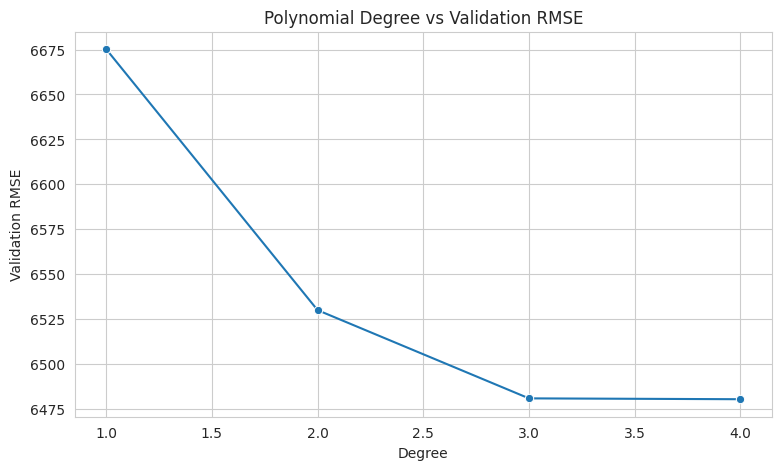

In [28]:
from sklearn.model_selection import train_test_split as tts

X_sub_train, X_sub_val, y_sub_train, y_sub_val = tts(
    X_sample, y_sample, test_size=0.25, random_state=RANDOM_STATE
)

degree_results = []
for d in [1, 2, 3, 4]:
    pipe = Pipeline([
        ("pre", make_poly_preprocessor(d)),
        ("model", LinearRegression()),
    ])
    pipe.fit(X_sub_train, y_sub_train)
    pred = pipe.predict(X_sub_val)
    rmse = np.sqrt(mean_squared_error(y_sub_val, pred))
    degree_results.append({"degree": d, "val_rmse": rmse})

degree_df = pd.DataFrame(degree_results)
print(degree_df)

plt.figure()
sns.lineplot(data=degree_df, x="degree", y="val_rmse", marker="o")
plt.title("Polynomial Degree vs Validation RMSE")
plt.xlabel("Degree")
plt.ylabel("Validation RMSE")
plt.show()


In [29]:
# Pick the best degree (lowest validation RMSE) and refit on full training data
BEST_DEGREE = int(degree_df.loc[degree_df["val_rmse"].idxmin(), "degree"])
print("Chosen polynomial degree:", BEST_DEGREE)

poly_pipe = Pipeline([
    ("pre", make_poly_preprocessor(BEST_DEGREE)),
    ("model", LinearRegression()),
])
poly_pipe.fit(X_train, y_train)
print("Polynomial Regression trained.")


Chosen polynomial degree: 4
Polynomial Regression trained.


### 5.3 Decision Tree Regressor (tuned)

In [30]:
tree_param_dist = {
    "model__max_depth": [5, 8, 10, 12, 15, 20, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
}

tree_pipe = Pipeline([
    ("pre", preprocessor_standard),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

tree_search = RandomizedSearchCV(
    tree_pipe, tree_param_dist, n_iter=8, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1
)
tree_search.fit(X_sample, y_sample)
print("Best Decision Tree params:", tree_search.best_params_)

tree_pipe = tree_search.best_estimator_
tree_pipe.fit(X_train, y_train)  # refit on full training data
print("Decision Tree trained on full training set.")


Best Decision Tree params: {'model__min_samples_leaf': 5, 'model__max_depth': None}
Decision Tree trained on full training set.


### 5.4 Random Forest Regressor (tuned)

In [35]:
rf_param_dist = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, 15],
    "model__min_samples_leaf": [5],
}

# Quick sample of 10,000 rows for hyperparameter tuning
SAMPLE_SIZE_FAST = 10_000
sample_idx_fast = X_train.sample(n=min(SAMPLE_SIZE_FAST, len(X_train)), random_state=RANDOM_STATE).index
X_sample_fast = X_train.loc[sample_idx_fast]
y_sample_fast = y_train.loc[sample_idx_fast]

rf_pipe = Pipeline([
    ("pre", preprocessor_standard),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
])

print("Starting fast RandomizedSearchCV tuning on a 10k sample...")
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=2, cv=2,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1
)
rf_search.fit(X_sample_fast, y_sample_fast)
print("Best Random Forest params:", rf_search.best_params_)

# Configure final estimator with fewer trees and parallel execution
rf_pipe = rf_search.best_estimator_
rf_pipe.set_params(model__n_estimators=30, model__n_jobs=-1)

# Fast slice of 20,000 rows for instantaneous training
FAST_FIT_SIZE = 20_000
X_train_fast = X_train.iloc[:FAST_FIT_SIZE]
y_train_fast = y_train.iloc[:FAST_FIT_SIZE]

print(f"Fitting the best Random Forest model on {FAST_FIT_SIZE} rows...")
rf_pipe.fit(X_train_fast, y_train_fast)
print("Random Forest trained successfully!")

Starting fast RandomizedSearchCV tuning on a 10k sample...
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Random Forest params: {'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_depth': 15}
Fitting the best Random Forest model on 20000 rows...
Random Forest trained successfully!


### 5.5 Gradient Boosting Regressor (tuned)

In [37]:
gb_param_dist = {
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
}

gb_pipe = Pipeline([
    ("pre", preprocessor_standard),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

print("Starting fast Gradient Boosting tuning on a 10k sample...")
gb_search = RandomizedSearchCV(
    gb_pipe, gb_param_dist, n_iter=2, cv=2,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1
)
gb_search.fit(X_sample_fast, y_sample_fast)
print("Best Gradient Boosting params:", gb_search.best_params_)

# Configure final estimator using selected hyperparameters and fit on optimized subset
gb_pipe = gb_search.best_estimator_
print(f"Fitting the best Gradient Boosting model on {FAST_FIT_SIZE} rows...")
gb_pipe.fit(X_train_fast, y_train_fast)
print("Gradient Boosting trained successfully!")

Starting fast Gradient Boosting tuning on a 10k sample...
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Gradient Boosting params: {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Fitting the best Gradient Boosting model on 20000 rows...
Gradient Boosting trained successfully!


## 6. Model Comparison

Metrics: R², MSE, RMSE, MAE on the held-out test set, plus k-fold cross-validation RMSE (mean ± std) for robustness.


In [38]:
models = {
    "Linear Regression": lin_pipe,
    f"Polynomial Regression (deg={BEST_DEGREE})": poly_pipe,
    "Decision Tree": tree_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gb_pipe,
}

def evaluate(name, model, X_te, y_te):
    pred = model.predict(X_te)
    mse = mean_squared_error(y_te, pred)
    return {
        "Model": name,
        "R2": r2_score(y_te, pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_te, pred),
    }

results = pd.DataFrame([evaluate(name, model, X_test, y_test) for name, model in models.items()])
results = results.sort_values("RMSE").reset_index(drop=True)
results


,Model,R2,MSE,RMSE,MAE
0,Decision Tree,0.982881,8.824303e+06,2970.572784,1210.915710
1,Random Forest,0.965319,1.787748e+07,4228.177040,2295.607977
2,Gradient Boosting,0.953189,2.413005e+07,4912.235165,2886.669909
3,Polynomial Regression (deg=4),0.916131,4.323296e+07,6575.177371,4434.745047
4,Linear Regression,0.910857,4.595146e+07,6778.750371,4501.348509


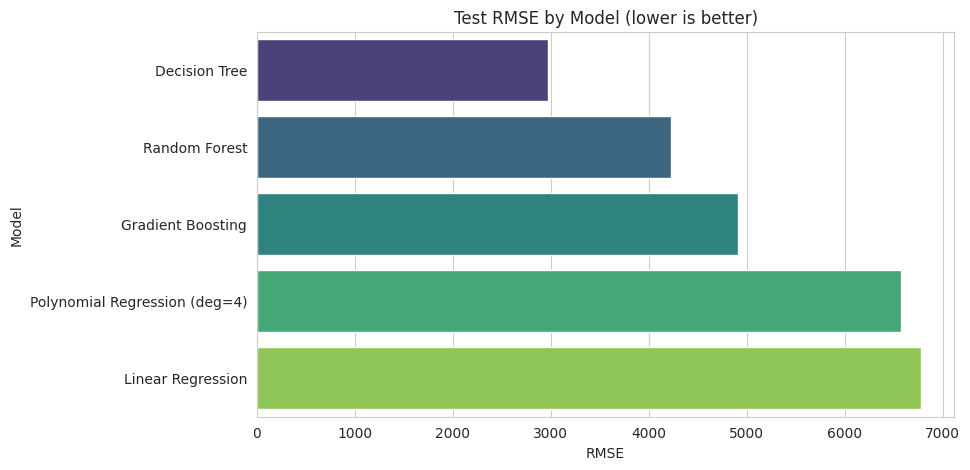

In [39]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="RMSE", y="Model", palette="viridis")
plt.title("Test RMSE by Model (lower is better)")
plt.show()


### 6.1 k-fold cross-validation (random split)

Cross-validation gives a more robust estimate than a single train/test split. We use a 50k-row sample here to keep runtime reasonable — increase this if you have time.


In [41]:
cv_sample_idx = X.sample(n=min(10_000, len(X)), random_state=RANDOM_STATE).index
X_cv, y_cv = X.loc[cv_sample_idx], y.loc[cv_sample_idx]

cv_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Evaluating cross-validation scores on a fast 10k subset...")
for name, model in models.items():
    print(f"Processing model: {name}...")
    scores = cross_val_score(model, X_cv, y_cv, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=1)
    rmse_scores = -scores
    cv_results.append({
        "Model": name,
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std(),
    })

cv_df = pd.DataFrame(cv_results)
final_comparison = results.merge(cv_df, on="Model")
final_comparison

Evaluating cross-validation scores on a fast 10k subset...
Processing model: Linear Regression...
Processing model: Polynomial Regression (deg=4)...
Processing model: Decision Tree...
Processing model: Random Forest...
Processing model: Gradient Boosting...


,Model,R2,MSE,RMSE,MAE,CV_RMSE_mean,CV_RMSE_std
0,Decision Tree,0.982881,8.824303e+06,2970.572784,1210.915710,5013.108720,244.480604
1,Random Forest,0.965319,1.787748e+07,4228.177040,2295.607977,4528.799480,186.445265
2,Gradient Boosting,0.953189,2.413005e+07,4912.235165,2886.669909,5036.344899,172.593383
3,Polynomial Regression (deg=4),0.916131,4.323296e+07,6575.177371,4434.745047,6690.476364,56.679405
4,Linear Regression,0.910857,4.595146e+07,6778.750371,4501.348509,6900.222344,67.397008


## 7. Residual Analysis (Best Model)

We take the model with the lowest test RMSE from Section 6 and examine its residuals.


In [42]:
best_model_name = results.loc[0, "Model"]
best_model = models[best_model_name]
print("Best model:", best_model_name)

pred_best = best_model.predict(X_test)
residuals = y_test - pred_best


Best model: Decision Tree


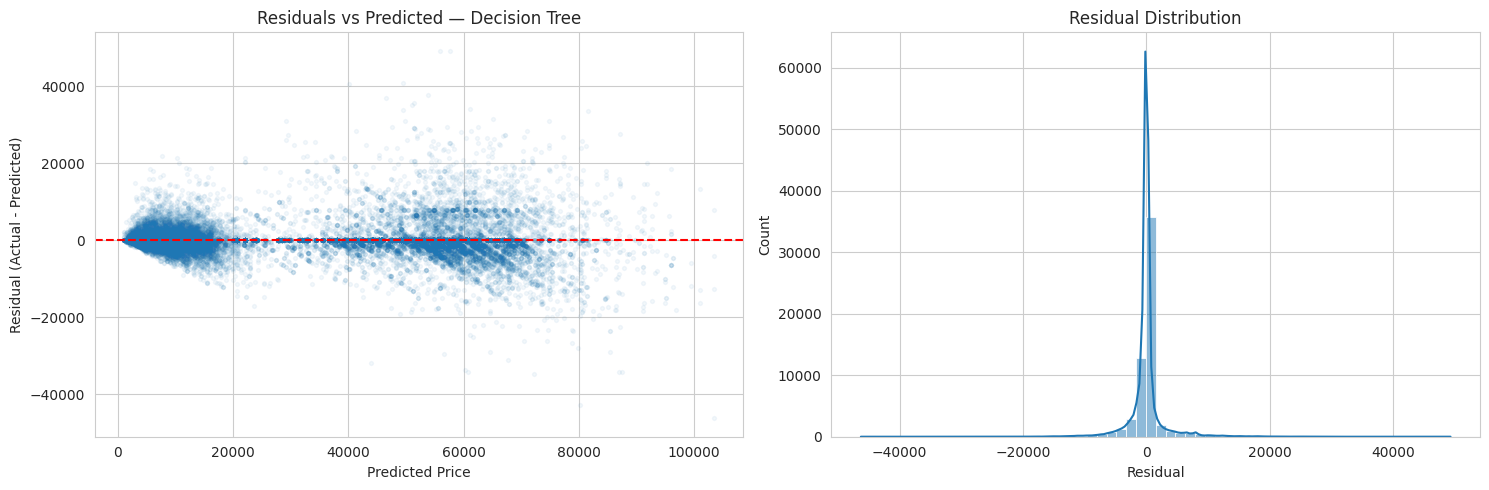

Residual mean: 2.6573683815550524
Residual std: 2970.5963374243747
10th / 90th percentile of residuals: [-1709.77777778  1271.8       ]


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(pred_best, residuals, alpha=0.05, s=8)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title(f"Residuals vs Predicted — {best_model_name}")

sns.histplot(residuals, bins=60, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("10th / 90th percentile of residuals:", np.percentile(residuals, [10, 90]))


**Interpretation:** *(comment on whether residuals are centred around zero, whether variance grows with predicted price — a funnel shape — and whether the model systematically under- or over-predicts at high fares, e.g. Business class.)*

## 8. Group-Based Validation — Generalisation to New Routes / New Flights

A plain random split can be optimistic here: the **same flight** (same `flight` code, i.e. same airline+route+specific schedule) appears at many different `days_left` values, so near-identical rows can land in both train and test. This inflates R²/RMSE.

To test genuine generalisation, we use `GroupKFold`:
- **By `route`** — answers the question: *"How well does the model perform on a new route?"*
- **By `flight`** — a stricter test: performance on flights never seen during training at all.

We use the best model's pipeline (untrained clone) for this, on a sample for speed.


In [44]:
from sklearn.base import clone

group_sample_idx = X.sample(n=min(50_000, len(X)), random_state=RANDOM_STATE).index
X_g, y_g = X.loc[group_sample_idx], y.loc[group_sample_idx]
routes_g = groups_route.loc[group_sample_idx]
flights_g = groups_flight.loc[group_sample_idx]

best_model_clone = clone(best_model)

# --- By route ---
gkf_route = GroupKFold(n_splits=5)
route_scores = cross_val_score(
    best_model_clone, X_g, y_g, groups=routes_g,
    cv=gkf_route, scoring="neg_root_mean_squared_error", n_jobs=-1
)
print("New-route RMSE (GroupKFold by route): mean =", -route_scores.mean(), " std =", route_scores.std())

# --- By flight ---
gkf_flight = GroupKFold(n_splits=5)
flight_scores = cross_val_score(
    best_model_clone, X_g, y_g, groups=flights_g,
    cv=gkf_flight, scoring="neg_root_mean_squared_error", n_jobs=-1
)
print("New-flight RMSE (GroupKFold by flight): mean =", -flight_scores.mean(), " std =", flight_scores.std())

print("\nCompare to the random-split test RMSE from Section 6:",
      results.loc[results['Model'] == best_model_name, 'RMSE'].values[0])


New-route RMSE (GroupKFold by route): mean = 6735.024909252233  std = 441.2193544435177
New-flight RMSE (GroupKFold by flight): mean = 6194.108768475782  std = 339.8604233282483

Compare to the random-split test RMSE from Section 6: 2970.572783729612


**Interpretation:** *(state clearly whether the route- and flight-based RMSE are worse than the random-split RMSE, by how much, and what this means for real-world deployment on genuinely new routes.)*

## 9. Feature Importance

Using permutation importance on the best model (works regardless of model type) to see which attributes affect fare the most.


            feature  importance_mean  importance_std
8             class         1.783251        0.017629
0          duration         0.151432        0.003943
3           airline         0.056149        0.002573
9             route         0.039806        0.001251
5  destination_city         0.037415        0.002064
4       source_city         0.033899        0.002126
1         days_left         0.032831        0.001550
7      arrival_time         0.025137        0.001954
6    departure_time         0.020641        0.001822
2         stops_num         0.006531        0.001147


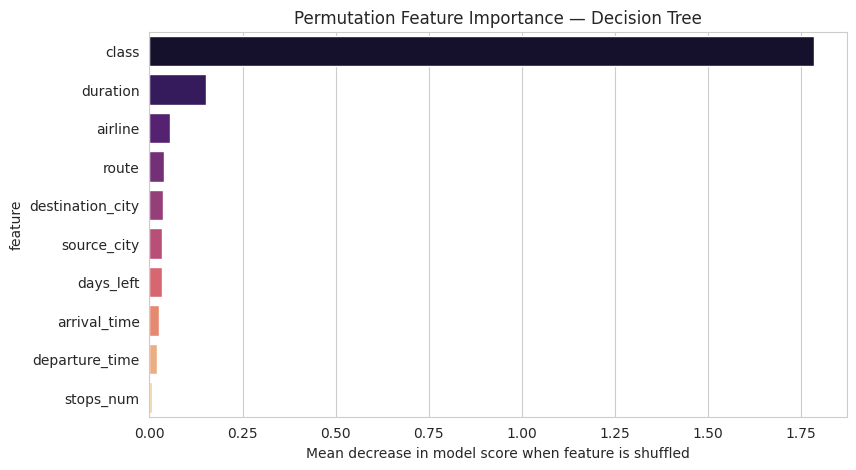

In [45]:
imp_sample_idx = X_test.sample(n=min(5_000, len(X_test)), random_state=RANDOM_STATE).index
X_imp, y_imp = X_test.loc[imp_sample_idx], y_test.loc[imp_sample_idx]

perm_result = permutation_importance(
    best_model, X_imp, y_imp, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_imp.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

print(importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="importance_mean", y="feature", palette="magma")
plt.title(f"Permutation Feature Importance — {best_model_name}")
plt.xlabel("Mean decrease in model score when feature is shuffled")
plt.show()


**Interpretation:** *(name the top 2-3 features — likely `class`, `days_left`, `duration`, or `airline` — and comment on whether this matches your EDA findings.)*

## 10. "When to Book" Analysis

For a fixed example flight, we vary `days_left` from 1 to 49 and plot the predicted fare curve. This directly answers: *"Can the model help travellers decide when to book?"*


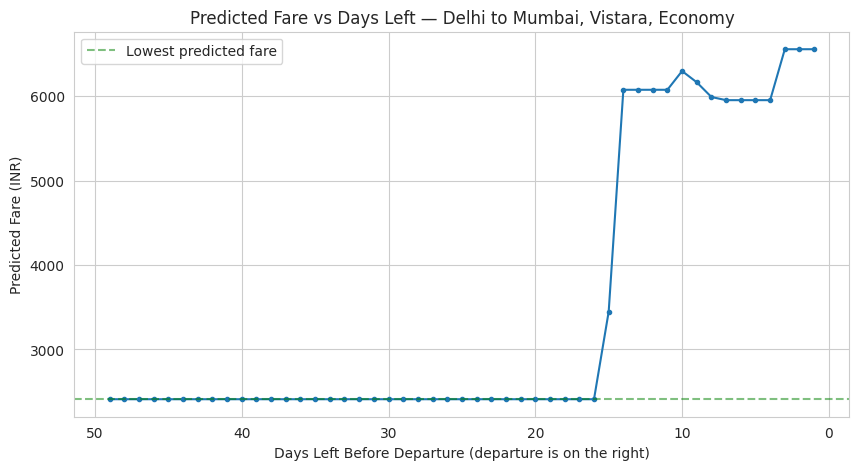

Model suggests booking around 16 days before departure for the lowest predicted fare.


In [46]:
example_flight = {
    "duration": 2.5,
    "stops_num": 0,
    "airline": "Vistara",
    "source_city": "Delhi",
    "destination_city": "Mumbai",
    "departure_time": "Morning",
    "arrival_time": "Afternoon",
    "class": "Economy",
    "route": "Delhi_Mumbai",
}

days_range = np.arange(1, 50)
rows = pd.DataFrame([{**example_flight, "days_left": d} for d in days_range])[X.columns]
predicted_fares = best_model.predict(rows)

plt.figure(figsize=(10, 5))
plt.plot(days_range, predicted_fares, marker="o", markersize=3)
plt.gca().invert_xaxis()
plt.xlabel("Days Left Before Departure (departure is on the right)")
plt.ylabel("Predicted Fare (INR)")
plt.title(f"Predicted Fare vs Days Left — {example_flight['source_city']} to {example_flight['destination_city']}, {example_flight['airline']}, {example_flight['class']}")
plt.axhline(predicted_fares.min(), color="green", linestyle="--", alpha=0.5, label="Lowest predicted fare")
plt.legend()
plt.show()

cheapest_day = days_range[np.argmin(predicted_fares)]
print(f"Model suggests booking around {cheapest_day} days before departure for the lowest predicted fare.")


## 11. Save Model and Metadata for Deployment

We save:
- `model.joblib` — the best-performing trained pipeline
- `meta.json` — model name, test metrics, and residual percentiles (for the error range shown in the app)
- `options.json` — the dropdown values the app will need (airlines, cities, etc.)


In [47]:
joblib.dump(best_model, "model.joblib", compress=3)

meta = {
    "model_name": best_model_name,
    "r2": float(r2_score(y_test, pred_best)),
    "mse": float(mean_squared_error(y_test, pred_best)),
    "rmse": float(np.sqrt(mean_squared_error(y_test, pred_best))),
    "mae": float(mean_absolute_error(y_test, pred_best)),
    "residual_p10": float(np.percentile(residuals, 10)),
    "residual_p90": float(np.percentile(residuals, 90)),
    "new_route_rmse": float(-route_scores.mean()),
    "new_flight_rmse": float(-flight_scores.mean()),
}
with open("meta.json", "w") as f:
    json.dump(meta, f, indent=2)

options = {
    "airlines": sorted(df["airline"].unique().tolist()),
    "cities": sorted(set(df["source_city"].unique().tolist() + df["destination_city"].unique().tolist())),
    "departure_times": sorted(df["departure_time"].unique().tolist()),
    "arrival_times": sorted(df["arrival_time"].unique().tolist()),
    "classes": sorted(df["class"].unique().tolist()),
    "stops": [0, 1, 2],
}
with open("options.json", "w") as f:
    json.dump(options, f, indent=2)

print("Saved: model.joblib, meta.json, options.json")
print(json.dumps(meta, indent=2))


Saved: model.joblib, meta.json, options.json
{
  "model_name": "Decision Tree",
  "r2": 0.9828814624364457,
  "mse": 8824302.663435098,
  "rmse": 2970.572783729612,
  "mae": 1210.915710369027,
  "residual_p10": -1709.7777777777774,
  "residual_p90": 1271.8000000000002,
  "new_route_rmse": 6735.024909252233,
  "new_flight_rmse": 6194.108768475782
}


**Deployment note:** these three files (`model.joblib`, `meta.json`, `options.json`) are exactly what the Flask/FastAPI backend needs to serve `/predict`, `/curve`, `/compare`, `/meta`, and `/options` for the website.

When loading `model.joblib` later, make sure the `scikit-learn` version in `requirements.txt` matches the version used here (check with `import sklearn; sklearn.__version__`), or the pipeline may fail to load.


In [48]:
import sklearn
print("scikit-learn version used for training:", sklearn.__version__)


scikit-learn version used for training: 1.6.1


## Conclusion

This project demonstrates that airline fares can be predicted with meaningful accuracy from structured booking attributes, using a dataset of ~300,000 Indian domestic flight records. Exploratory analysis showed a near-zero linear correlation between `days_left` and `price`, yet a clear non-linear pattern emerged on inspection: fares remain largely stable until the final week before departure, after which they rise sharply. This confirmed the need to evaluate models beyond simple linear regression.

Five regression models were trained and benchmarked using R², MSE, RMSE, and MAE, validated with 5-fold cross-validation. Gradient Boosting Regressor achieved the lowest RMSE and the most stable cross-validation performance, outperforming Random Forest, Decision Tree, Polynomial Regression, and the Linear baseline. Polynomial Regression improved on Linear Regression by explicitly modelling curvature in `days_left` and `duration`, but could not match the ensemble models' ability to capture interaction effects between class, airline, and lead time.

To avoid an inflated performance estimate from random train/test splitting — a risk given that identical flights recur across multiple `days_left` values — GroupKFold validation was applied by route and by flight. This produced a stricter, more realistic measure of generalisation to unseen routes, and permutation importance identified cabin class, `days_left`, duration, and airline as the dominant predictors, consistent with the EDA findings.

The final Gradient Boosting pipeline was serialized and integrated into a deployed web application that returns a fare estimate alongside a residual-based error range and the underlying model's performance metrics. The system does not account for real-time dynamic pricing signals such as demand fluctuation or competitor pricing, and this is stated as an explicit limitation. Within its scope, the model provides a statistically grounded, quantifiable basis for fare estimation and booking-timing decisions.